# ARM (Auto Regression Model) for timeseries forecasting

## Imports

In [14]:
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt

## Reading the dataset

In [2]:
df = pd.read_csv('../data/1_Daily_minimum_temps.csv')
df

,Date,Temp
0,01/01/81,20.7
1,01/02/81,17.9
2,01/03/81,18.8
3,01/04/81,14.6
4,01/05/81,15.8
...,...,...
3645,12/27/90,14
3646,12/28/90,13.6
3647,12/29/90,13.5
3648,12/30/90,15.7


## Pre-processing

In [3]:
df['Temp'] = df['Temp'].replace(r'[^\d\.]', '', regex=True)
df

,Date,Temp
0,01/01/81,20.7
1,01/02/81,17.9
2,01/03/81,18.8
3,01/04/81,14.6
4,01/05/81,15.8
...,...,...
3645,12/27/90,14
3646,12/28/90,13.6
3647,12/29/90,13.5
3648,12/30/90,15.7


In [4]:
type_mapping = {
    'Date': 'datetime64[ns]',
    'Temp': 'float',
}
df = df.astype(type_mapping)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


### Timeseries visualization

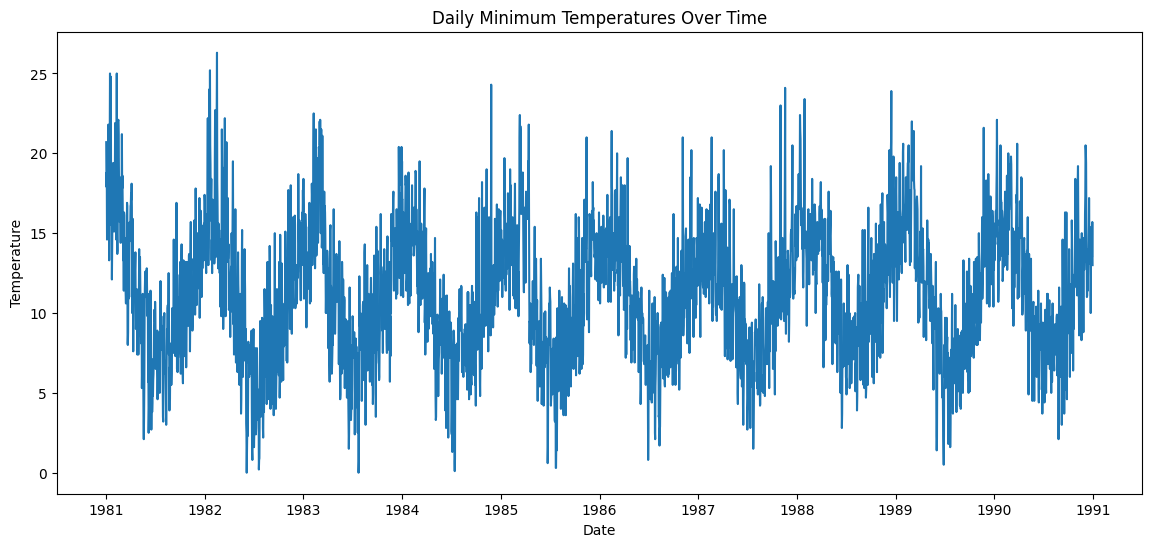

In [25]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Temp'])
plt.title('Daily Minimum Temperatures Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.show()

### Summary of dataset

In [6]:
df.describe()

,Date,Temp
count,3650,3650.000000
mean,1985-12-31 07:12:00,11.177753
min,1981-01-01 00:00:00,0.000000
25%,1983-07-02 06:00:00,8.300000
50%,1985-12-31 12:00:00,11.000000
75%,1988-06-30 18:00:00,14.000000
max,1990-12-31 00:00:00,26.300000
std,NaN,4.071837


## Forecasting preparation

In [43]:
X=df.values
X

array([[Timestamp('1981-01-01 00:00:00'), 20.7],
       [Timestamp('1981-01-02 00:00:00'), 17.9],
       [Timestamp('1981-01-03 00:00:00'), 18.8],
       ...,
       [Timestamp('1990-12-29 00:00:00'), 13.5],
       [Timestamp('1990-12-30 00:00:00'), 15.7],
       [Timestamp('1990-12-31 00:00:00'), 13.0]], dtype=object)

### Check for stationality
Use augmented dickey-fuller test. If p-value is less than 0.5, then it is non-stationary, else it is stationary.

In [22]:
from statsmodels.tsa.stattools import adfuller

adf_test_res = adfuller(x=df['Temp'], autolag='AIC')

print("ADF: ", adf_test_res[0])
print("P-value: ", adf_test_res[1])
print("No. of lags: ", adf_test_res[2])
print("Number of observations used for ADF and critical value calculation: ", adf_test_res[3])
print("Critical values: ")
for key, val in adf_test_res[4].items():
    print(f"\t{key} : {val}")

ADF:  -4.444804924611696
P-value:  0.0002470826300361034
No. of lags:  20
Number of observations used for ADF and critical value calculation:  3629
Critical values: 
	1% : -3.4321532327220154
	5% : -2.862336767636517
	10% : -2.56719413172842


### Checking the optimal previous values

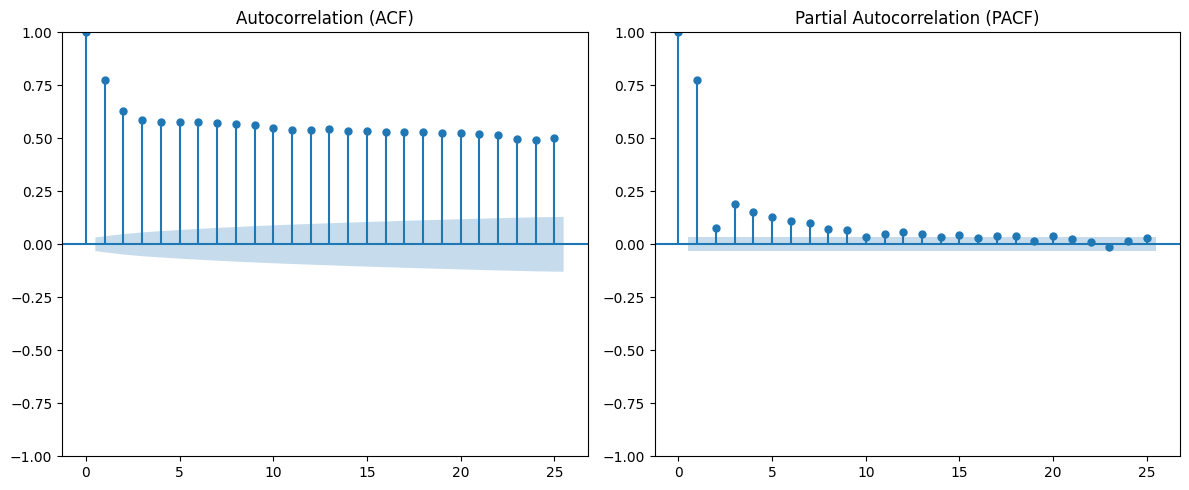

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set up subplots to display both ACF and PACF in one figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot ACF on the first subplot and PACF on the second subplot
plot_acf(df['Temp'], lags=25, ax=axes[0])
plot_pacf(df['Temp'], lags=25, ax=axes[1])

# Set titles for clarity
axes[0].set_title("Autocorrelation (ACF)")
axes[1].set_title("Partial Autocorrelation (PACF)")

# Display the combined plots in a single figure
plt.tight_layout()
plt.show()

# Forecasting

## Train and test split

In [44]:
train = X[:(len(X) - 7)]
test = X[(len(X) - 7):]

In [47]:
len(train), len(test)

(3643, 7)

In [68]:
for val in test:
    print(val[1])

12.9
14.6
14.0
13.6
13.5
15.7
13.0


## Model training

In [52]:
model = AutoReg(endog=df['Temp'], lags=10).fit()
model

## Model Summary

In [55]:
print(model.summary())

                            AutoReg Model Results                             
Dep. Variable:                   Temp   No. Observations:                 3650
Model:                    AutoReg(10)   Log Likelihood               -8389.120
Method:               Conditional MLE   S.D. of innovations              2.425
Date:                Mon, 28 Oct 2024   AIC                          16802.241
Time:                        22:15:00   BIC                          16876.638
Sample:                            10   HQIC                         16828.739
                                 3650                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9336      0.141      6.598      0.000       0.656       1.211
Temp.L1        0.6099      0.017     36.821      0.000       0.577       0.642
Temp.L2       -0.0832      0.019     -4.293      0.0

## Forecasting

In [59]:
forecasts = model.predict(start = len(train), end = len(X) - 1, dynamic=False)
forecasts

3643    11.481972
3644    13.506882
3645    14.138631
3646    13.537290
3647    13.290730
3648    13.264148
3649    14.482813
dtype: float64

### Forecast visualization

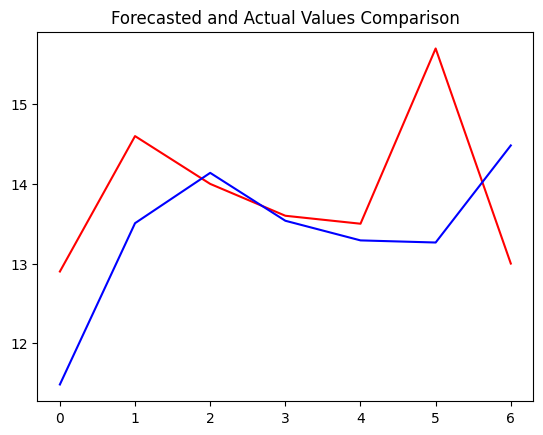

Actual values [12.9, 14.6, 14.0, 13.6, 13.5, 15.7, 13.0]
Forecasts [11.48197246 13.50688243 14.13863084 13.53729022 13.29073042 13.26414778
 14.48281314]


In [78]:
test_vals = [val[1] for val in test]

plt.title('Forecasted and Actual Values Comparison')
plt.plot(test_vals, color='red')
plt.plot(forecasts.values, color='blue')
plt.show()

print("Actual values", test_vals)
print("Forecasts",forecasts.values)

### Error calculation

In [79]:
from math import sqrt
from sklearn.metrics import mean_squared_error

rmse = sqrt(mean_squared_error(test_vals, forecasts.values))
print("RMSE: ", rmse)

RMSE:  1.2764215482296444


### Future forecasts

In [92]:
future_forecasts = model.predict(start = (len(X) + 1), end = (len(X) + 7), dynamic=False)
future_forecasts

3651    12.935632
3652    13.011246
3653    13.151508
3654    13.186248
3655    13.170526
3656    13.060355
3657    13.020199
dtype: float64

In [93]:
len(future_forecasts)

7